In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def gaussian_kernel(x, y, sigma, corr_length):
    """
    Compute the Gaussian kernel for two points (x, y) in 2D.
    """
    sqdist = np.sum((x - y) ** 2)
    return sigma ** 2 * np.exp(-sqdist / (2 * corr_length ** 2))

def kl_expand(grid_size, sigma, corr_length):
    """
    Generates multiple Gaussian random fields on a 2D grid using KL expansion.
    
    Parameters:
    grid_size : int - Size of the grid (grid_size x grid_size)
    sigma : float - Standard deviation of the Gaussian field
    corr_length : float - Correlation length of the Gaussian field
    kl_ndim : int - Number of KL expansion modes to retain
    num_samples : int - Number of random field samples to generate
    
    Returns:
    fields : 3D numpy array - The generated Gaussian random fields (num_samples x grid_size x grid_size)
    kl_values : 1D numpy array - The KL expansion eigenvalues (square root of the eigenvalues of the covariance matrix)
    kl_modes : 2D numpy array - The KL expansion modes (eigenvectors of the covariance matrix)
    """
    # Create a grid of points
    x = np.linspace(-2, 2, grid_size)
    y = np.linspace(-2, 2, grid_size)
    xx, yy = np.meshgrid(x, y)
    points = np.vstack([xx.ravel(), yy.ravel()]).T
    
    # Calculate the covariance matrix
    n_points = grid_size * grid_size
    cov_matrix = np.zeros((n_points, n_points))
    
    for i in range(n_points):
        for j in range(i, n_points):
            cov_matrix[i, j] = gaussian_kernel(points[i], points[j], sigma, corr_length)
            cov_matrix[j, i] = cov_matrix[i, j]
    
    # Perform eigenvalue decomposition
    w, v = np.linalg.eigh(cov_matrix)
    
    # Sort eigenvalues and eigenvectors in descending order
    w = w[::-1]
    v = v[:, ::-1]
    
    # Select the first `kl_ndim` eigenvalues and eigenvectors
    kl_values = np.sqrt(np.abs(w))
    kl_modes = v[:, :]
    
    return kl_values, kl_modes

# Parameters
grid_size = 101       # Size of the grid (51x51)
sigma = 1.0          # Standard deviation of the Gaussian field
corr_length = 0.15   # Correlation length

# Generate the Gaussian random fields
kl_values, kl_modes= kl_expand(grid_size, sigma, corr_length)

In [ ]:
def gradient_background(m, n, a, grand_v, delta_h):
    v = np.arange(m) * delta_h * grand_v + a
    matrix = np.kron(v.reshape(m, 1), np.ones((1, n)))
    return matrix

def generate_gaussian_random_fields(kl_values,kl_modes,kl_ndim, num_samples):  
    
    print('Sum kl_value',sum(kl_values))
    kl_values=kl_values[10:10+kl_ndim]
    print('Sum kl_value[:kl_dim]',sum(kl_values))
    kl_modes = kl_modes[:, 10:10+kl_ndim]
    z = np.random.randn(num_samples,kl_ndim)
    gradient = np.random.uniform(0.03, 0.06, size=(num_samples, 1))

    z = np.hstack((z, gradient))
    # Generate multiple samples using KL expansion
    fields = np.zeros((num_samples, grid_size, grid_size))
    for k in range(num_samples):

        field = np.dot(kl_modes, z[k,:-1])
        background = gradient_background(grid_size, grid_size, 0, z[k,-1], 4/(grid_size-1))
        fields[k] = np.exp(field).reshape((grid_size, grid_size)) + background
#         
    return fields, z

kl_ndim = 20        # Number of KL expansion modes to retain
num_samples = 100000     # Number of random field samples to generate

fields, z = generate_gaussian_random_fields(kl_values,kl_modes,kl_ndim, num_samples)

# fields = 
# mean_trans = 1
# fields = mean_trans+1.5*mean_trans*fields/(fields.max()-fields.min())

print('fields_trans.min()',fields.min())
print('fields_trans.max()',fields.max())
print('fields_trans.mean()',fields.mean())

Sum kl_value 2242.16889508428
Sum kl_value[:kl_dim] 170.07983742844107
fields_trans.min() 0.7502301175874418
fields_trans.max() 1.4787114714286644
fields_trans.mean() 1.0909512418295522


## KL-modes

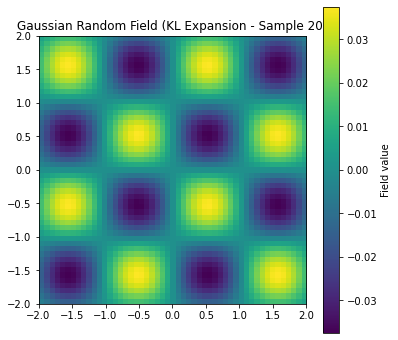

In [39]:
import time
from IPython.display import clear_output
for i in range(10,10+kl_ndim):
    clear_output(wait=True)
    plt.figure(figsize=(6, 6))
    plt.imshow(kl_modes[:,i].reshape(grid_size,grid_size), extent=(-2, 2, -2, 2), cmap='viridis')
    plt.colorbar(label='Field value')
    plt.title(f'Gaussian Random Field (KL Expansion - Sample {i+1})')
    plt.show()
    time.sleep(0.2)

## Gaussian feilds

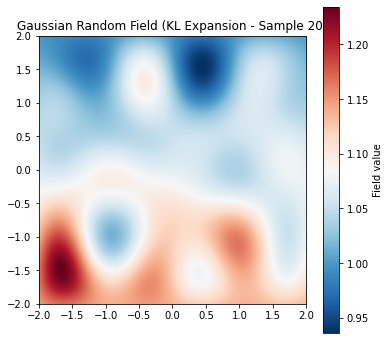

In [20]:
import time
from IPython.display import clear_output

# Plot the gaussian field 
for i in range(20):
    clear_output(wait=True)
    plt.figure(figsize=(6, 6))
    plt.imshow(fields[i], extent=(-2, 2, -2, 2), cmap='RdBu_r')
    plt.colorbar(label='Field value')
    plt.title(f'Gaussian Random Field (KL Expansion - Sample {i+1})')
    plt.show()
    time.sleep(0.2)



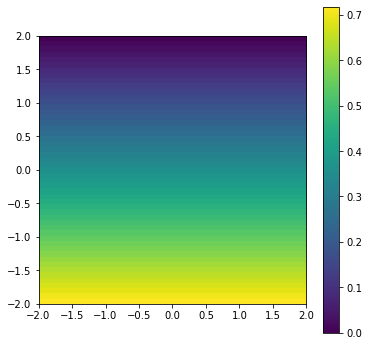

In [ ]:
def gradient_background(m, n, a, grand_v, delta_h):
    v = np.arange(m) * delta_h * grand_v + a

    matrix = v.reshape(m, 1) @  np.ones((1, n))

    return matrix

background = gradient_background(grid_size, grid_size, 0, z[0,-1], 4/(grid_size-1))
plt.figure(figsize=(6, 6))

plt.imshow(background, extent=(-2, 2, -2, 2), cmap='viridis')
plt.colorbar()
plt.show()


In [ ]:
import numpy as np
import skfmm
import matplotlib.pyplot as plt
from tqdm import trange
from scipy.ndimage import distance_transform_edt as distance

def Eikonal(F_sample,initial_point, delta,plt_show = False):

    F = F_sample

    # F_value = F_value.reshape(10,10)
    # assign_to_submatrices(F[:,:], F_value)
    
    T = np.full_like(F_sample, np.inf)

    # initial_index = (np.where(y == initial_point[1])[0], np.where(x == initial_point[0])[0])
    initial_index = (np.where(y == initial_point[1])[0], np.where(x == initial_point[0])[0])

    T[initial_index] = 0

    mask = np.ones_like(F_sample, dtype=bool)
    mask[initial_index] = False
    phi = -distance(mask) + distance(~mask)
    T = np.ma.MaskedArray(T, mask)

    T = skfmm.travel_time(phi, F , dx=delta)
    if plt_show == True:
        plt.imshow(T,interpolation='none',extent=[-2, 2, -2, 2], cmap='RdBu_r', aspect='equal', vmin=0)
        plt.plot(initial_point[0],initial_point[1], 'wo')  # 初始点标记为白色圆圈
        plt.colorbar(label='Travel time')
        plt.show()

    return T


########################################################
mesh_x = grid_size
mesh_y = grid_size
delta = 4/(grid_size-1)
x = np.linspace(-2, 2, mesh_x)
y = np.linspace(2, -2, mesh_y)
X, Y = np.meshgrid(x, y)

N_sample = num_samples

# F2_sample = np.random.uniform(0.5,1.5,[N_sample,10*10])



T_time = np.zeros([N_sample,grid_size,grid_size])

initial_point = np.array([0,0])

pbar = trange(N_sample)
for i in range(N_sample):
    clear_output(wait=True)
    F_sample = fields[i]
    T_time[i] = Eikonal(F_sample,initial_point, delta,plt_show = False)
    if i%(N_sample/10)==0:
        print(f"{i}/{N_sample} sample have been generated")

    


##########################################################
np.savez('Gaussian_fields_data.npz', kl_values=kl_values[10:10+kl_ndim], kl_modes=kl_modes[:, 10:10+kl_ndim],kl_z=z,T_time=T_time, v_fields = fields)

print('all done')


all done
